In [179]:
from lagp.utils.integration import (
    simulate_grouped_response, compute_naive_log_marglik, gpboost_nll_min_dec, compute_aghq, run_simulation
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
plt.style.use('ggplot')

group_size = 100
num_groups = 10
re_std = 1
quantile = 0.8
scale = 0.8
misspecified = False

approx = "asymmetric_laplace_constant_curvature_fisher_mode_finding"
min_dec = 10
# quadrature points
K = 100


Y, _ = simulate_grouped_response(group_size= group_size, 
                                 num_groups= num_groups,
                                 re_mean= 0,
                                 re_std= re_std,
                                 quantile = quantile,
                                 scale = scale,
                                 misspecified= misspecified
                                 )

naive = compute_naive_log_marglik(Y = Y, group_size= group_size, num_groups=num_groups,quantile=quantile,scale=scale, re_std=re_std)
gpq, gpboost_ll, gpboost_ll_current= gpboost_nll_min_dec(Y=Y, laplace_approx= approx, min_dec = min_dec, num_groups=num_groups, group_size=group_size, quantile = quantile, scale = scale)
predicted_re = gpq.predict_training_data_random_effects(predict_var=True)
aghq = compute_aghq(Y= Y, group_size=group_size, num_groups=num_groups, predicted_re=predicted_re, quantile=quantile, scale = scale, re_std = re_std, K = K)


[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.265046, delta_log_like_up_ = 10.025, delta_log_like_down_ = 10.1406
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 14, delta_mode_ = 0.168151, delta_log_like_up_ = 11.8916, delta_log_like_down_ = 12.3652
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.214989, delta_log_like_up_ = 12.2373, delta_log_like_down_ = 10.6473
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.318013, delta_log_like_up_ = 17.8774, delta_log_like_down_ = 18.3225
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.316991, delta_log_like_up_ = 15.8395, delta_log_like_down_ = 16.1031
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.256046, delta_log_like_up_ = 10.3442, delta_log_like_down_ = 10.0188
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16,

In [180]:
# check that for low group size, naive and aghq yield the same result --> they do!

In [181]:
print(gpboost_ll)
print(f"Current: {gpboost_ll_current}")
print(f"Naive: {naive}")
print(f"Adaptive GH: {aghq}")

2615.988924384441
Current: 2615.9761087318248
Naive: 2616.2523537048933
Adaptive GH: 2616.0507377006566


<BarContainer object of 4 artists>

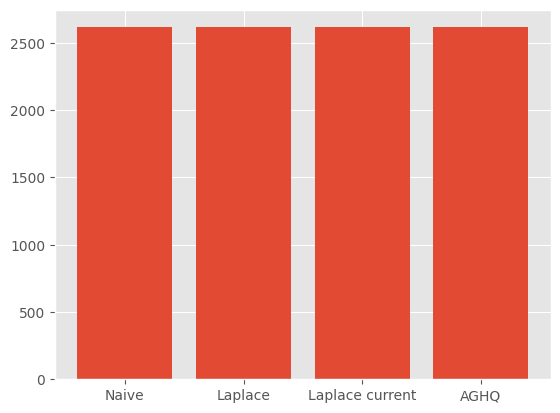

In [182]:
# Plot
plt.bar(["Naive", "Laplace", "Laplace current", "AGHQ"], [naive, gpboost_ll, gpboost_ll_current, aghq])

In [183]:
# check in simulation how close the different aghq results are!!!

In [184]:
# test simulation
B = 10
min_decreases = [10, 100]
results = {}
group_sizes = [50, 100, 500]
for group_size in group_sizes:
    gps, naives, aghqs = run_simulation(
        laplace_approximation=approx, # fix laplace approx
        group_size=group_size,
        num_groups=num_groups,
        re_mean=0,
        re_std=re_std,
        scale=scale,
        quantile=quantile,
        min_decreases=min_decreases,
        K = K,
        B=B,
        misspecified=misspecified
    )
    results[group_size] = {"gps": gps, "naives": naives, "aghqs": aghqs}



[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 18, delta_mode_ = 0.915667, delta_log_like_up_ = 41.9888, delta_log_like_down_ = 58.4697
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.313244, delta_log_like_up_ = 19.046, delta_log_like_down_ = 22.2239
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.298791, delta_log_like_up_ = 10.0157, delta_log_like_down_ = 14.0347
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.349777, delta_log_like_up_ = 10.0174, delta_log_like_down_ = 14.4619
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.377803, delta_log_like_up_ = 10.0006, delta_log_like_down_ = 14.4956
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.393441, delta_log_like_up_ = 10.0075, delta_log_like_down_ = 14.608
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 18, 

C:\Users\JumpStart\Documents\projects\LaGP\src\lagp\utils\integration.py:38: RuntimeWarning: divide by zero encountered in log
  res += np.log(integral)


[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.348546, delta_log_like_up_ = 71.6518, delta_log_like_down_ = 75.9726
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 14, delta_mode_ = 0.202683, delta_log_like_up_ = 26.4596, delta_log_like_down_ = 26.0267
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 14, delta_mode_ = 0.202683, delta_log_like_up_ = 26.5591, delta_log_like_down_ = 26.1226
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.344824, delta_log_like_up_ = 70.2918, delta_log_like_down_ = 73.9606
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 16, delta_mode_ = 0.341064, delta_log_like_up_ = 68.6211, delta_log_like_down_ = 72.1544
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 14, delta_mode_ = 0.202683, delta_log_like_up_ = 26.5186, delta_log_like_down_ = 26.0851
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 14, delta_mode_ = 0.202683, delta_log_like_up_ = 26.5195, de

In [185]:
all_diffs = []

for group_size, result in results.items(): #loop over sample_sizes
    gps = result["gps"]
    aghqs = result["aghqs"]

    for min_dec, gp_vals in gps.items(): # loop over min_decreases
        aghq_vals = aghqs[min_dec] # since for now I recompute for each min_decrease

        diffs = ( np.array(gp_vals) - np.array(aghq_vals) ) / (np.array(aghq_vals))
        all_diffs.extend([
            {
                "sample_size": group_size,
                "min_dec_ll": min_dec,
                "value": diff
            }
            for diff in diffs
        ])

df_long = pd.DataFrame(all_diffs)
df_long["sample_size"] = df_long["sample_size"].astype(int)
df_long = df_long.sort_values(by="sample_size")

In [186]:
df_long.head()

,sample_size,min_dec_ll,value
0,50,10,-0.000953
1,50,10,-0.000986
2,50,10,-0.000810
3,50,10,-0.000180
4,50,10,-0.000467


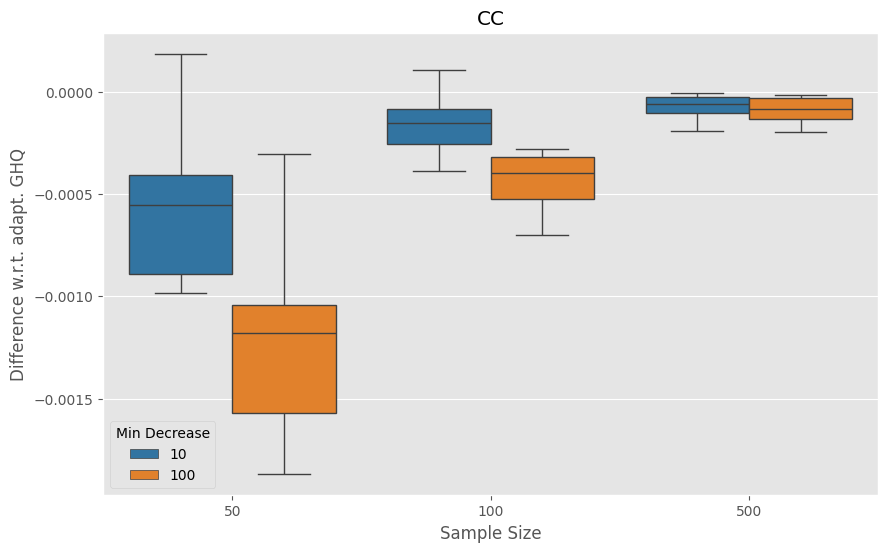

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [187]:

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_long,
    x="sample_size",
    y="value",
    hue="min_dec_ll",
    palette="tab10",
    patch_artist=True,
    showmeans=False,
    showfliers=False,
    meanline=True
)
plt.xlabel("Sample Size")
plt.ylabel("Difference w.r.t. adapt. GHQ")
plt.title("CC", color="black")
legend = plt.legend(title="Min Decrease", labelcolor="black")
legend.get_title().set_color("black")
plt.show()
plt.figure(figsize=(10, 6))

In [188]:
# take only one group and test visualization of posterior
from lagp.utils.posteriors import plot_posteriors, laplace_approx
group_size = 100 # make it match with above !!
Y_1 = Y[:group_size]

In [189]:
approx = "asymmetric_laplace_constant_curvature_fisher_mode_finding"
min_dec = 10
predicted_re, laplace_mean, laplace_var, nll= laplace_approx(Y = Y_1, approx = approx, min_dec= min_dec, quantile=quantile, num_groups=1, group_size=group_size)

[GPBoost] [Info] Using CC_LLS_MIN_DECREASE_LOG_LIKE_ = 10
[GPBoost] [Warning] There is no intercept for modeling a possibly non-zero mean of the random effects. Consider including an intercept (= a column of 1's) in the covariates 'X' 
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.21709, delta_log_like_up_ = 11.4515, delta_log_like_down_ = 14.6241
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.21683, delta_log_like_up_ = 31.115, delta_log_like_down_ = 39.7337
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 0.885512, delta_log_like_up_ = 11.202, delta_log_like_down_ = 13.4554
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.21683, delta_log_like_up_ = 14.4122, delta_log_like_down_ = 18.4044
[GPBoost] [Info] FindDeltaMode_LLS_CC_Approximation: it = 19, delta_mode_ = 1.21683, delta_log_like_up_ = 14.8142, delta_log_like_down_ = 18.9177
[GPBoost] [Info] FindDeltaMode_LLS_

In [190]:
laplace_mean

np.float64(-0.5471364447149467)

In [191]:
laplace_var

np.float64(0.04173872489492328)

In [192]:
print(nll)

258.3713809858102


In [193]:
# return NNL -> so need to change sign
log_normalising_constant = - compute_aghq(Y = Y_1, group_size=group_size, num_groups=1, predicted_re=predicted_re, quantile=quantile, scale = scale, re_std = re_std, K = K)

In [194]:
log_normalising_constant

np.float64(-258.60308298164927)

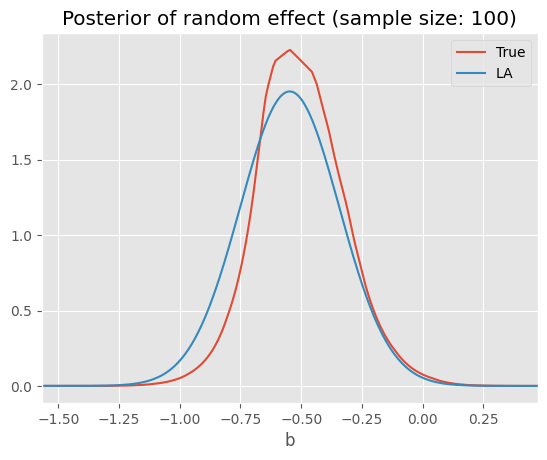

In [195]:
bs = np.linspace(-5,5, 1000)
plot_posteriors(bs = bs, Y = Y_1, quantile = quantile, scale = scale, re_std = re_std, laplace_mean=laplace_mean, laplace_var = laplace_var, log_normalising_constant= log_normalising_constant)